# Ransomware Communication Analysis: Linguistic Patterns & Financial Tiers – Phase 2 Analysis

## Overview
This notebook investigates whether linguistic tone in ransomware communications influences criminal success. We test whether "niceness" (measured through politeness and service-oriented language) is associated with financial performance or organisational survival.

The analysis is divided into two tracks:

- **Track A:** Examines whether linguistic tone predicts total revenue among high-earning ransomware groups.
- **Track B:** Tests whether tone influences organisational longevity among smaller or mid-market groups.

## Methodology
1. **Data Ingestion:** Compiled ransomware group data including revenue estimates, operational timelines, and ransom note text samples.
2. **Feature Construction:** Generated linguistic metrics including Net Politeness, Service Score, and Aggression Score.
3. **Statistical Modelling:**  
   - OLS regression models for revenue (Track A) and longevity (Track B)  
   - Spearman correlations (non-parametric robustness)  
   - Robust standard errors (HC3)  
   - Time-period controls (post-2021 dummy)  
   - Outlier sensitivity analysis (e.g., exclusion of GandCrab)  
   - **Victim Payment Capacity (VPC) Index** structural control for victim-type targeting advantage (see §4 below)
4. **Decomposition Analysis:** Separated service-oriented language from aggressive language to identify underlying mechanisms.

### Control Variable: Victim Payment Capacity (VPC) Index

Tests whether `Net_Politeness` retains predictive power after controlling for the structural advantage of targeting high-paying victims (enterprise vs. consumer). A `VPC_Index` score (1.0 = consumer/home user targets → 5.0 = critical infrastructure) is derived as:

**VPC = (Victim Size Score + Sector Sensitivity Score) / 2**

`VPC_Index` is assigned to each group in Cell 2 and applied in four regression specifications per track:

1. **VPC standalone** validates VPC as a real predictor before using it as a control
2. **Net_Politeness + VPC** core causal test: does language still predict revenue after removing victim-type advantage?
3. **Full model** adds `post_2021` for triple-controlled specification
4. **Interaction model** tests the "Desperate Middle Manager" hypothesis: does the language-revenue slope differ across victim tiers?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.formula.api as smf
from scipy.stats import spearmanr, pearsonr

# --- Academic Style Config ---
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',         # Matches the previous charts
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.labelweight': 'normal',
    'axes.spines.top': False,          # Remove top spine
    'axes.spines.right': False,        # Remove right spine
    'axes.linewidth': 0.8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'grid.color': '#DDDDDD',
    'grid.linewidth': 0.5,
    'figure.dpi': 300,                 # High-res for Word
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
})

# Load datasets (ensure CSVs are in the same folder as this notebook)
df_trackA = pd.read_csv('trackA_analysis.csv')
df_trackB = pd.read_csv('trackB_analysis.csv')

print("Track A Columns:", df_trackA.columns.tolist())
print("Track B Columns:", df_trackB.columns.tolist())

# ── CONTROL VARIABLE: Victim Payment Capacity (VPC) Index ───────────────────
# VPC = (Victim Size Score + Sector Sensitivity Score) / 2
# Scale: 1.0 = consumer/home user targets → 5.0 = critical infrastructure
#
# Victim Size Score (VSS)        Sector Sensitivity Score (SSS)
#   1 = Consumer/Individual        5 = Energy / Critical Infrastructure
#   2 = SMB                        4.5 = Healthcare
#   3 = SMB-Enterprise             4 = Education / Government
#   4 = Enterprise / BGH           3.5 = Manufacturing
#                                  2 = SMB General
#                                  1 = Consumer / General Public

vpc_trackA = {
    'gandcrab':     1.00,  # Consumer spray-and-pray; self-claimed $2B via volume, not BGH
    'lockbit':      3.75,  # Enterprise BGH; cross-sector (finance, health, energy, govt)
    'cryptowall':   1.50,  # Mass-market; home users + small business; $300-$10K demands
    'akira':        3.50,  # SMB-Enterprise; healthcare, finance, education; $200K-millions
    'conti':        4.25,  # Enterprise BGH; healthcare, govt, finance; multi-million demands
    'ryuk':         4.25,  # Enterprise BGH; healthcare, govt, education; hundreds of thousands
    'revil':        3.75,  # Enterprise BGH; mixed sectors; $200K-$70M range
    'blackbasta':   3.50,  # Enterprise; Conti offshoot; $1.2M average
    'clop':         4.00,  # Enterprise; MOVEit/GoAnywhere; healthcare, finance, manufacturing
    'hive':         4.25,  # Enterprise BGH; healthcare + critical infrastructure; FBI top target
    'darkside':     4.50,  # Enterprise; energy/critical infra (Colonial Pipeline); $1.9M avg
    'avaddon':      2.50,  # SMB; mixed targeting; $600K average; 2,934 decryption keys
    'alphv':        3.75,  # Enterprise BGH; healthcare, hospitality, gaming; several million
    'maze':         3.75,  # Enterprise; double-extortion pioneer; mixed BGH sectors
    'darkangels':   4.50,  # Healthcare-exclusive BGH; $75M single payment record
    'cuba':         3.50,  # Enterprise; financial, govt, healthcare, manufacturing
    'netwalker':    3.00,  # SMB-Enterprise; healthcare, education, govt; $65K avg
    'doppelpaymer': 3.25,  # Enterprise; BitPaymer successor; manufacturing, healthcare
    'cryptolocker': 1.25,  # Consumer + small business; $300-$500 demands; Operation Tovar
    'dharma':       2.00,  # SMB; RDP-exposed small business; $500-$50K demands
    'phobos':       2.25,  # SMB; healthcare, education, small biz; $54K average
    'locky':        1.50,  # Mass-market consumer; $200-$800; Necurs botnet distribution
    'cerber':       1.50,  # Mass-market consumer; $500-$1000; 40% developer RaaS cut
    'samsam':       4.25,  # Enterprise; healthcare + govt + education; $25K-$64K targeted
    'wannacry':     1.00,  # Indiscriminate wiper/ransomware; $300-$600; consumer/global
    'torrentlocker':1.50,  # Consumer; AU/UK/Europe spam; $1M total
    'qlocker':      2.00,  # Consumer-SMB; QNAP NAS devices; $350K in days; 0.01 BTC
    'bianlian':     3.25,  # SMB-Enterprise; exfiltration-only 2023; Makop-linked
    'medusa':       3.75,  # SMB-Enterprise; healthcare, govt, education; $100K-$15M
    'royal':        3.50,  # Enterprise; healthcare, manufacturing, comms; $1M-$11M
    'bitpaymer':    3.50,  # Enterprise; EvilCorp; predecessor to DoppelPaymer; $25K-$1.2M
    'embargo':      4.50,  # Enterprise; Rust-based; healthcare-targeting RaaS
    'spora':        1.50,  # Consumer; $0.8M total; praised payment portal


}

vpc_trackB = {
    'stop':         1.00,  # Consumer; pirated software; 460K+ home users; $490-$980
    'petya':        2.00,  # Mixed; enterprise + consumer; wiper (NotPetya); 0.9 BTC
    'magniber':     1.25,  # Consumer; Korean/Asian home users; PrintNightmare
    'teslacrypt':   1.00,  # Consumer gamers; master key released; $76 BTC demands
    'shade':        1.25,  # Consumer; Russia/CIS targeted; 750K decryption keys released
    'ctblocker':    1.50,  # Consumer + WordPress; Tor C2; affiliate model
    'jigsaw':       1.25,  # Consumer; $150 BTC; deleted files hourly
    'xorist':       1.25,  # Consumer; low sophistication; $50-$500 demands
    'keranger':     1.50,  # Consumer; macOS via BitTorrent client; brief campaign
    'jaff':         2.00,  # SMB; Necurs botnet; 0.5-2 BTC; mass spam
    'globeimposter':2.00,  # SMB; Necurs distributed; Globe ransomware mimic
    'play':         3.50,  # Enterprise; ~900 victims; no dark web portal; email-based
    'ransomhub':    3.50,  # Enterprise RaaS; 736 victims 2024; ex-Cyclops/Knight
    'qilin':        4.00,  # Enterprise BGH; healthcare + manufacturing; most active Q3 2025
    'matrix':       2.00,  # SMB; RDP-targeted; multiple variants; low-profile
    'satan':        2.00,  # SMB; low-barrier RaaS; variants DBGer/Lucky
    'pysa':         4.00,  # Enterprise BGH; education + healthcare; Mespinoza variant
    'cactus':       3.25,  # SMB-Enterprise; VPN exploitation; self-encrypting
    'inc':          3.50,  # Enterprise; INC Ransom; increasing activity Q3 2025
    'badrabbit':    2.00,  # Mixed; Russia/Ukraine media; 0.05 BTC; NotPetya-linked
    'makop':        2.00,  # SMB; low ransoms; BianLian-linked; persistent family
    '8base':        2.75,  # SMB-Enterprise; Phobos variant; 69 victims Q1 2024
    'karakurt':     3.75,  # Enterprise; data-theft only; Conti division; $25K-$13M
    'egregor':      3.75,  # Enterprise; Maze successor; 197 victims; arrested 2021
    'rhysida':      3.25,  # SMB-Enterprise; education, healthcare; Vice Society-linked
    'vicesociety':  3.25,  # SMB-Enterprise; education-heavy; multiple ransomware strains
    'snatch':       3.00,  # Enterprise; safe-mode bypass; CISA advisory 2023
    'satana':       2.00,  # Mixed; MBR locker + file encryptor; 0.5 BTC
    'avoslocker':   3.25,  # SMB-Enterprise; critical infrastructure; Linux variant
    'ransomhouse':  3.50,  # Enterprise; AMD breach 2022; self-described mediators
    'blackbyte':    4.50,  # Enterprise; US critical infrastructure; ProxyShell; FBI warning
    'fog':          3.00,  # SMB-Enterprise; education + VPN; rapid encryption
    'stormous':     2.50,  # Mixed; hacktivist-ransomware hybrid; pro-Russia; GhostSec
    'lorenz':       2.75,  # SMB; Mitel VoIP exploitation; data-theft focus
    'ragnarlocker': 3.50,  # Enterprise; semi-private; 52 orgs in 10 sectors; Europol seized
    'blackmatter':  3.50,  # Enterprise; DarkSide rebrand; $5.3M avg; 4-month operation
    'monti':        3.25,  # Enterprise; Conti copycat; Linux/ESXi targeting
    'mamba':        3.00,  # Enterprise; DiskCryptor full-disk; FBI warning 2021
    'knight':       2.50,  # SMB; Cyclops rebrand; sold source code
    'babuk':        3.75,  # Enterprise BGH; DC Metro Police; leaked code 2021
    'megacortex':   3.75,  # Enterprise BGH; operators arrested 2021; large enterprises
    'nephilim':     3.50,  # Enterprise; Nemty successor; Citrix vulnerabilities
    'nokoyawa':     3.25,  # SMB-Enterprise; Hive-linked; Windows CLFS zero-day
    'trigona':      3.25,  # SMB-Enterprise; wiped by Ukrainian Cyber Alliance Oct 2023
    'nemty':        2.25,  # SMB; rebranded to Nephilim; brief RaaS forum activity
    'suncrypt':     3.50,  # Enterprise; Maze cartel connection; brief operation
    'robinhood':    3.75,  # Government; Baltimore ($76K demand, $18M recovery cost)
}

df_trackA['VPC_Index'] = df_trackA['group_name'].str.lower().str.strip().map(vpc_trackA)
df_trackB['VPC_Index'] = df_trackB['group_name'].str.lower().str.strip().map(vpc_trackB)

missing_a = df_trackA[df_trackA['VPC_Index'].isna()]['group_name'].tolist()
missing_b = df_trackB[df_trackB['VPC_Index'].isna()]['group_name'].tolist()

print(f"\nVPC_Index added: Track A {df_trackA['VPC_Index'].notna().sum()}/{len(df_trackA)} mapped, Track B {df_trackB['VPC_Index'].notna().sum()}/{len(df_trackB)} mapped")
if missing_a: print(f"  ⚠ Track A unmapped groups: {missing_a}")
if missing_b: print(f"  ⚠ Track B unmapped groups: {missing_b}")
print("\nVPC_Index distribution (Track A):")
print(df_trackA[['group_name','VPC_Index']].sort_values('VPC_Index', ascending=False).to_string(index=False))


Track A Columns: ['group_name', 'time_window_start', 'time_window_end', 'total_estimated_revenue_usd', 'confirmed_victims', 'source_label', 'notes', 'log_revenue', 'Tier', 'Service_Score', 'Aggression_Score', 'Net_Politeness']
Track B Columns: ['group_name', 'first_seen', 'last_seen', 'status', 'leaksite_victim_count', 'longevity_months', 'campaign_volume', 'notes', 'log_volume', 'Tier', 'Service_Score', 'Aggression_Score', 'Net_Politeness']

VPC_Index added: Track A 33/33 mapped, Track B 47/47 mapped

VPC_Index distribution (Track A):
   group_name  VPC_Index
   darkangels       4.50
      embargo       4.50
     darkside       4.50
         hive       4.25
        conti       4.25
       samsam       4.25
         ryuk       4.25
         clop       4.00
         maze       3.75
       medusa       3.75
        alphv       3.75
        revil       3.75
      lockbit       3.75
        royal       3.50
         cuba       3.50
        akira       3.50
   blackbasta       3.50
    bitp

### TRACK A REGRESSION - BASELINE MODEL
#### GROUPS WITH AVAILABLE REVENUE

This block runs the correlation and regression to see if "niceness" predicts higher revenue for elite groups.

--- TRACK A: REVENUE ANALYSIS ---
Correlation (Politeness vs Revenue): -0.354
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     4.450
Date:                Thu, 23 Apr 2026   Prob (F-statistic):             0.0431
Time:                        20:14:48   Log-Likelihood:                -67.958
No. Observations:                  33   AIC:                             139.9
Df Residuals:                      31   BIC:                             142.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

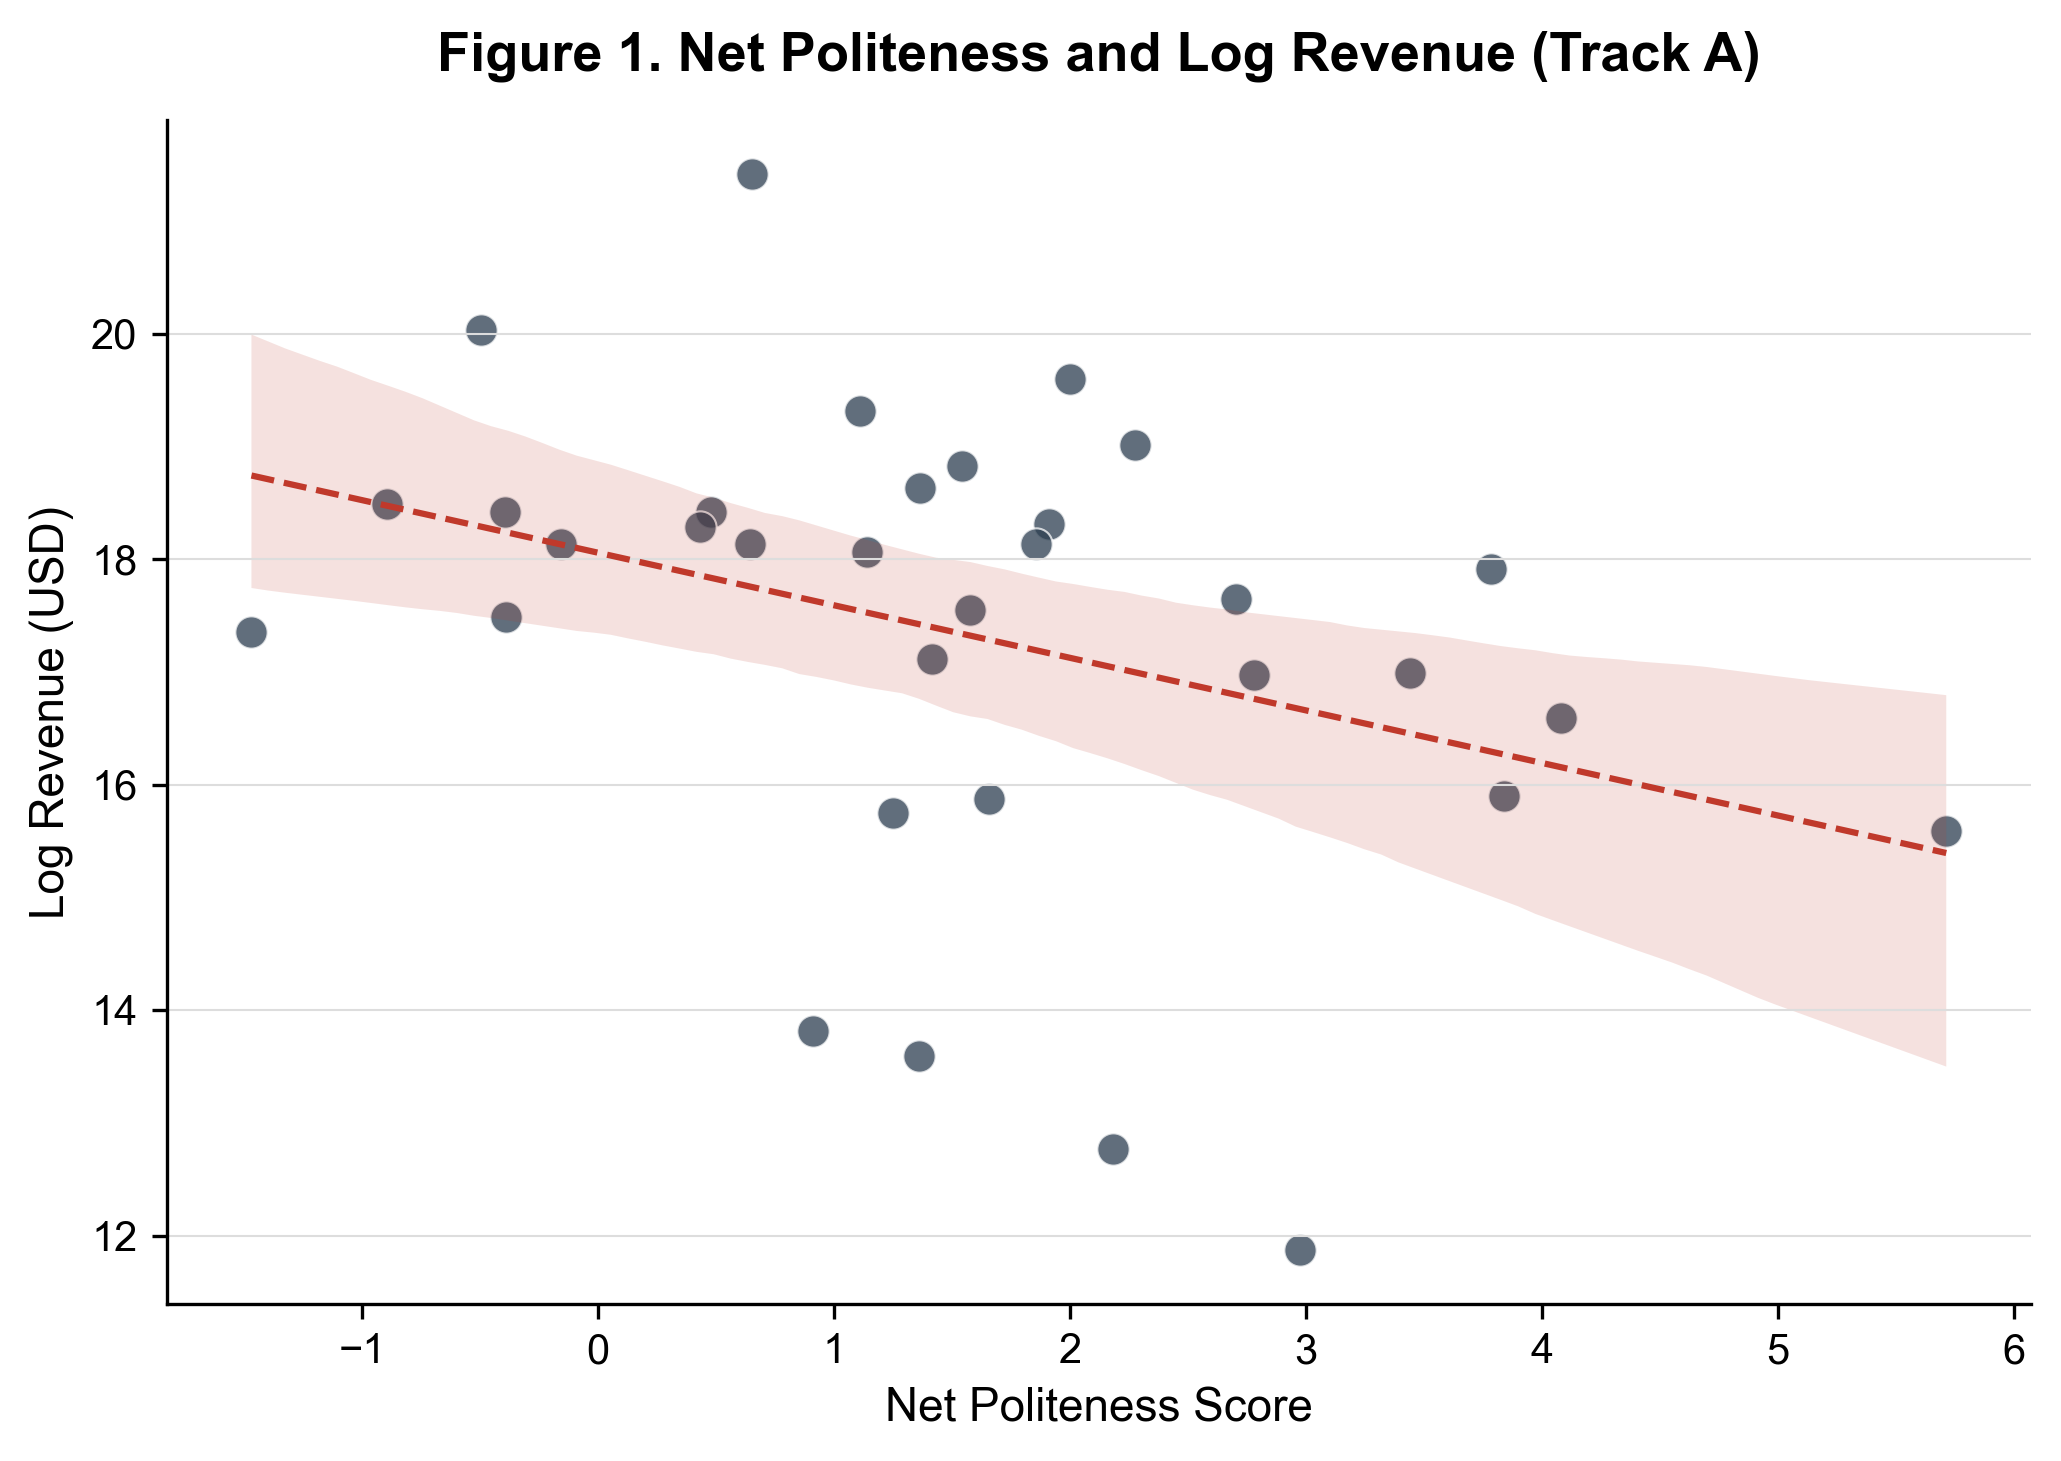

In [2]:
print("--- TRACK A: REVENUE ANALYSIS ---")

# 1. Pearson Correlation
# This gives a single number between -1 (perfect negative) and +1 (perfect positive)
corr_a = df_trackA['Net_Politeness'].corr(df_trackA['log_revenue'])
print(f"Correlation (Politeness vs Revenue): {corr_a:.3f}")

# 2. Linear Regression Model
# Formula: log_revenue = Intercept + Net_Politeness
model_a = smf.ols("log_revenue ~ Net_Politeness", data=df_trackA).fit()
print(model_a.summary())

# 3. Visualization
fig, ax = plt.subplots(figsize=(7, 5))  # Narrower — fits Word column width

sns.regplot(
    x='Net_Politeness', y='log_revenue',
    data=df_trackA,
    ax=ax,
    scatter_kws={
        's': 60,
        'color': '#2C3E50',       # Dark navy — prints well in B&W
        'alpha': 0.75,
        'edgecolors': 'white',
        'linewidths': 0.5
    },
    line_kws={
        'color': '#C0392B',       # Muted red regression line
        'linewidth': 1.5,
        'linestyle': '--'
    },
    ci=95                          # Keep confidence interval
)

ax.set_title('Figure 1. Net Politeness and Log Revenue (Track A)',
             pad=12)
ax.set_xlabel('Net Politeness Score')
ax.set_ylabel('Log Revenue (USD)')
ax.yaxis.grid(True)                # Horizontal gridlines only
ax.xaxis.grid(False)

plt.tight_layout()
plt.savefig('TrackA_Revenue_Regression.png')
plt.show()


In [3]:
print("--- TRACK A: SPEARMAN VS PEARSON ---")

# Calculate Pearson (assumes normal distribution)
pe_a, p_pe_a = pearsonr(df_trackA['Net_Politeness'], df_trackA['log_revenue'])

# Calculate Spearman (rank-based, does NOT assume normal distribution)
sp_a, p_sp_a = spearmanr(df_trackA['Net_Politeness'], df_trackA['log_revenue'])

print(f"Pearson:  r = {pe_a:.3f}, p = {p_pe_a:.3f}")
print(f"Spearman: r = {sp_a:.3f}, p = {p_sp_a:.3f}")

# If the Spearman 'p' is still < 0.05, our finding is valid even if data isn't perfectly bell-curve shaped


--- TRACK A: SPEARMAN VS PEARSON ---
Pearson:  r = -0.354, p = 0.043
Spearman: r = -0.415, p = 0.016


In [4]:
print("--- TRACK A: ROBUST STANDARD ERRORS (HC3) ---")

# Running the same model but correcting for unequal variance (heteroskedasticity)
model_a_robust_se = smf.ols("log_revenue ~ Net_Politeness", data=df_trackA).fit(cov_type='HC3')
print(model_a_robust_se.summary())

--- TRACK A: ROBUST STANDARD ERRORS (HC3) ---
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     9.018
Date:                Thu, 23 Apr 2026   Prob (F-statistic):            0.00525
Time:                        20:14:51   Log-Likelihood:                -67.958
No. Observations:                  33   AIC:                             139.9
Df Residuals:                      31   BIC:                             142.9
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [5]:
print("--- TRACK A: CONTROLLING FOR TIME (POST-2021) ---")

# Create a binary dummy variable: 1 if year is 2021 or later, 0 if earlier
df_trackA['post_2021'] = (pd.to_datetime(df_trackA['time_window_start']).dt.year >= 2021).astype(int)

# Run the regression with both Politeness and Time as predictors
model_a_time = smf.ols("log_revenue ~ Net_Politeness + post_2021", data=df_trackA).fit(cov_type='HC3')
print(model_a_time.summary())

# Does Net_Politeness still have a negative 'coef' and a P-value < 0.05? 
# If yes, our finding survives the "it's just because of the 2021 boom" counter-argument.


--- TRACK A: CONTROLLING FOR TIME (POST-2021) ---
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     4.590
Date:                Thu, 23 Apr 2026   Prob (F-statistic):             0.0182
Time:                        20:14:51   Log-Likelihood:                -67.749
No. Observations:                  33   AIC:                             141.5
Df Residuals:                      30   BIC:                             146.0
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [6]:
print("--- TRACK A: DECOMPOSING AGGRESSION VS. SERVICE ---")

# Testing the two raw scores instead of the combined Net score
model_a_decomp = smf.ols("log_revenue ~ Service_Score + Aggression_Score", data=df_trackA).fit(cov_type='HC3')
print(model_a_decomp.summary())

# Checking the P-values for BOTH variables. Which one is driving the result? 
# Does Aggression increase revenue (positive coef), or does Service decrease it?


--- TRACK A: DECOMPOSING AGGRESSION VS. SERVICE ---
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     4.141
Date:                Thu, 23 Apr 2026   Prob (F-statistic):             0.0258
Time:                        20:14:51   Log-Likelihood:                -67.942
No. Observations:                  33   AIC:                             141.9
Df Residuals:                      30   BIC:                             146.4
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [7]:
print("--- TRACK A: REMOVING EXTREME OUTLIER CRIME GROUP (GANDCRAB) ---")

# Create a temporary dataframe that excludes gandcrab
# (Using .str.lower() just in case of capitalization differences)
df_trackA_no_outlier = df_trackA[df_trackA['group_name'].str.lower() != 'gandcrab']

# Run the model without GandCrab
model_a_no_outlier = smf.ols("log_revenue ~ Net_Politeness", data=df_trackA_no_outlier).fit(cov_type='HC3')
print(model_a_no_outlier.summary())

# If this is still significant, thesis is still strong. 
# If it loses significance, GandCrab was pulling the line down heavily.


--- TRACK A: REMOVING EXTREME OUTLIER CRIME GROUP (GANDCRAB) ---
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     8.263
Date:                Thu, 23 Apr 2026   Prob (F-statistic):            0.00737
Time:                        20:14:51   Log-Likelihood:                -64.385
No. Observations:                  32   AIC:                             132.8
Df Residuals:                      30   BIC:                             135.7
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

### TRACK A REGRESSION - VPC CONTROLLED MODEL

In [8]:
print("--- TRACK A: VPC STANDALONE (validation) ---")
model_a_vpc_only = smf.ols("log_revenue ~ VPC_Index", data=df_trackA).fit(cov_type='HC3')
print(model_a_vpc_only.summary())
print("EXPECT: Positive, significant coefficient — confirms VPC is a valid structural predictor.")

# ── Core Causal Test ────────────────────────────────────────────────────────
print("\n--- TRACK A: NET POLITENESS + VPC (core causal test) ---")
model_a_vpc = smf.ols("log_revenue ~ Net_Politeness + VPC_Index", data=df_trackA).fit(cov_type='HC3')
print(model_a_vpc.summary())
print("KEY: If Net_Politeness coef is still negative and p<0.05 → language effect is real,")
print("     not a proxy for BGH group structure.")

# ── Full Triple-Controlled Model ────────────────────────────────────────────
print("\n--- TRACK A: FULL MODEL (Net_Politeness + VPC + post_2021) ---")
model_a_full_vpc = smf.ols("log_revenue ~ Net_Politeness + VPC_Index + post_2021", data=df_trackA).fit(cov_type='HC3')
print(model_a_full_vpc.summary())
print("KEY: Most defensible specification. Controls for victim type AND era simultaneously.")

# ── Interaction: Desperate Middle Manager Test ───────────────────────────────
print("\n--- TRACK A: INTERACTION TEST (Desperate Middle Manager hypothesis) ---")
model_a_interact = smf.ols("log_revenue ~ Net_Politeness * VPC_Index", data=df_trackA).fit(cov_type='HC3')
print(model_a_interact.summary())
print("KEY: Significant Net_Politeness:VPC_Index term = language effect varies by victim tier.")
print("     Mid-VPC groups (SMB targets) should show the steepest language-to-revenue slope.")

# ── Summary comparison ──────────────────────────────────────────────────────
vpc_summary = pd.DataFrame({
    'Model': [
        'Baseline (Net_Politeness only)',
        'Time Control (+ post_2021)',
        'VPC Control (+ VPC_Index)',
        'Full Model (+ VPC + post_2021)',
        'Interaction (Net_Pol × VPC)',
    ],
    'Net_Politeness_coef': [
        model_a_no_outlier.params.get('Net_Politeness', float('nan')),
        model_a_time.params.get('Net_Politeness', float('nan')),
        model_a_vpc.params.get('Net_Politeness', float('nan')),
        model_a_full_vpc.params.get('Net_Politeness', float('nan')),
        model_a_interact.params.get('Net_Politeness', float('nan')),
    ],
    'p_value': [
        model_a_no_outlier.pvalues.get('Net_Politeness', float('nan')),
        model_a_time.pvalues.get('Net_Politeness', float('nan')),
        model_a_vpc.pvalues.get('Net_Politeness', float('nan')),
        model_a_full_vpc.pvalues.get('Net_Politeness', float('nan')),
        model_a_interact.pvalues.get('Net_Politeness', float('nan')),
    ],
    'R_squared': [
        model_a_no_outlier.rsquared,
        model_a_time.rsquared,
        model_a_vpc.rsquared,
        model_a_full_vpc.rsquared,
        model_a_interact.rsquared,
    ],
})
vpc_summary['significant'] = vpc_summary['p_value'] < 0.05
print("\n=== TRACK A ROBUSTNESS SUMMARY (all specifications) ===")
print(vpc_summary.round(4).to_string(index=False))


--- TRACK A: VPC STANDALONE (validation) ---
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     2.936
Date:                Thu, 23 Apr 2026   Prob (F-statistic):             0.0966
Time:                        20:14:51   Log-Likelihood:                -66.873
No. Observations:                  33   AIC:                             137.7
Df Residuals:                      31   BIC:                             140.7
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Interce

### TRACK B REGRESSION - BASELINE MODEL
#### GROUPS WITH AVAILABLE OPERATIONAL SUCCESS MEASURES
This block runs two separate models: one for Longevity (survival time) and one for Volume (number of victims).



--- TRACK B: MID-MARKET ANALYSIS ---
Correlation (Politeness vs Longevity): -0.088
                            OLS Regression Results                            
Dep. Variable:       longevity_months   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.3491
Date:                Thu, 23 Apr 2026   Prob (F-statistic):              0.558
Time:                        20:14:51   Log-Likelihood:                -230.59
No. Observations:                  47   AIC:                             465.2
Df Residuals:                      45   BIC:                             468.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

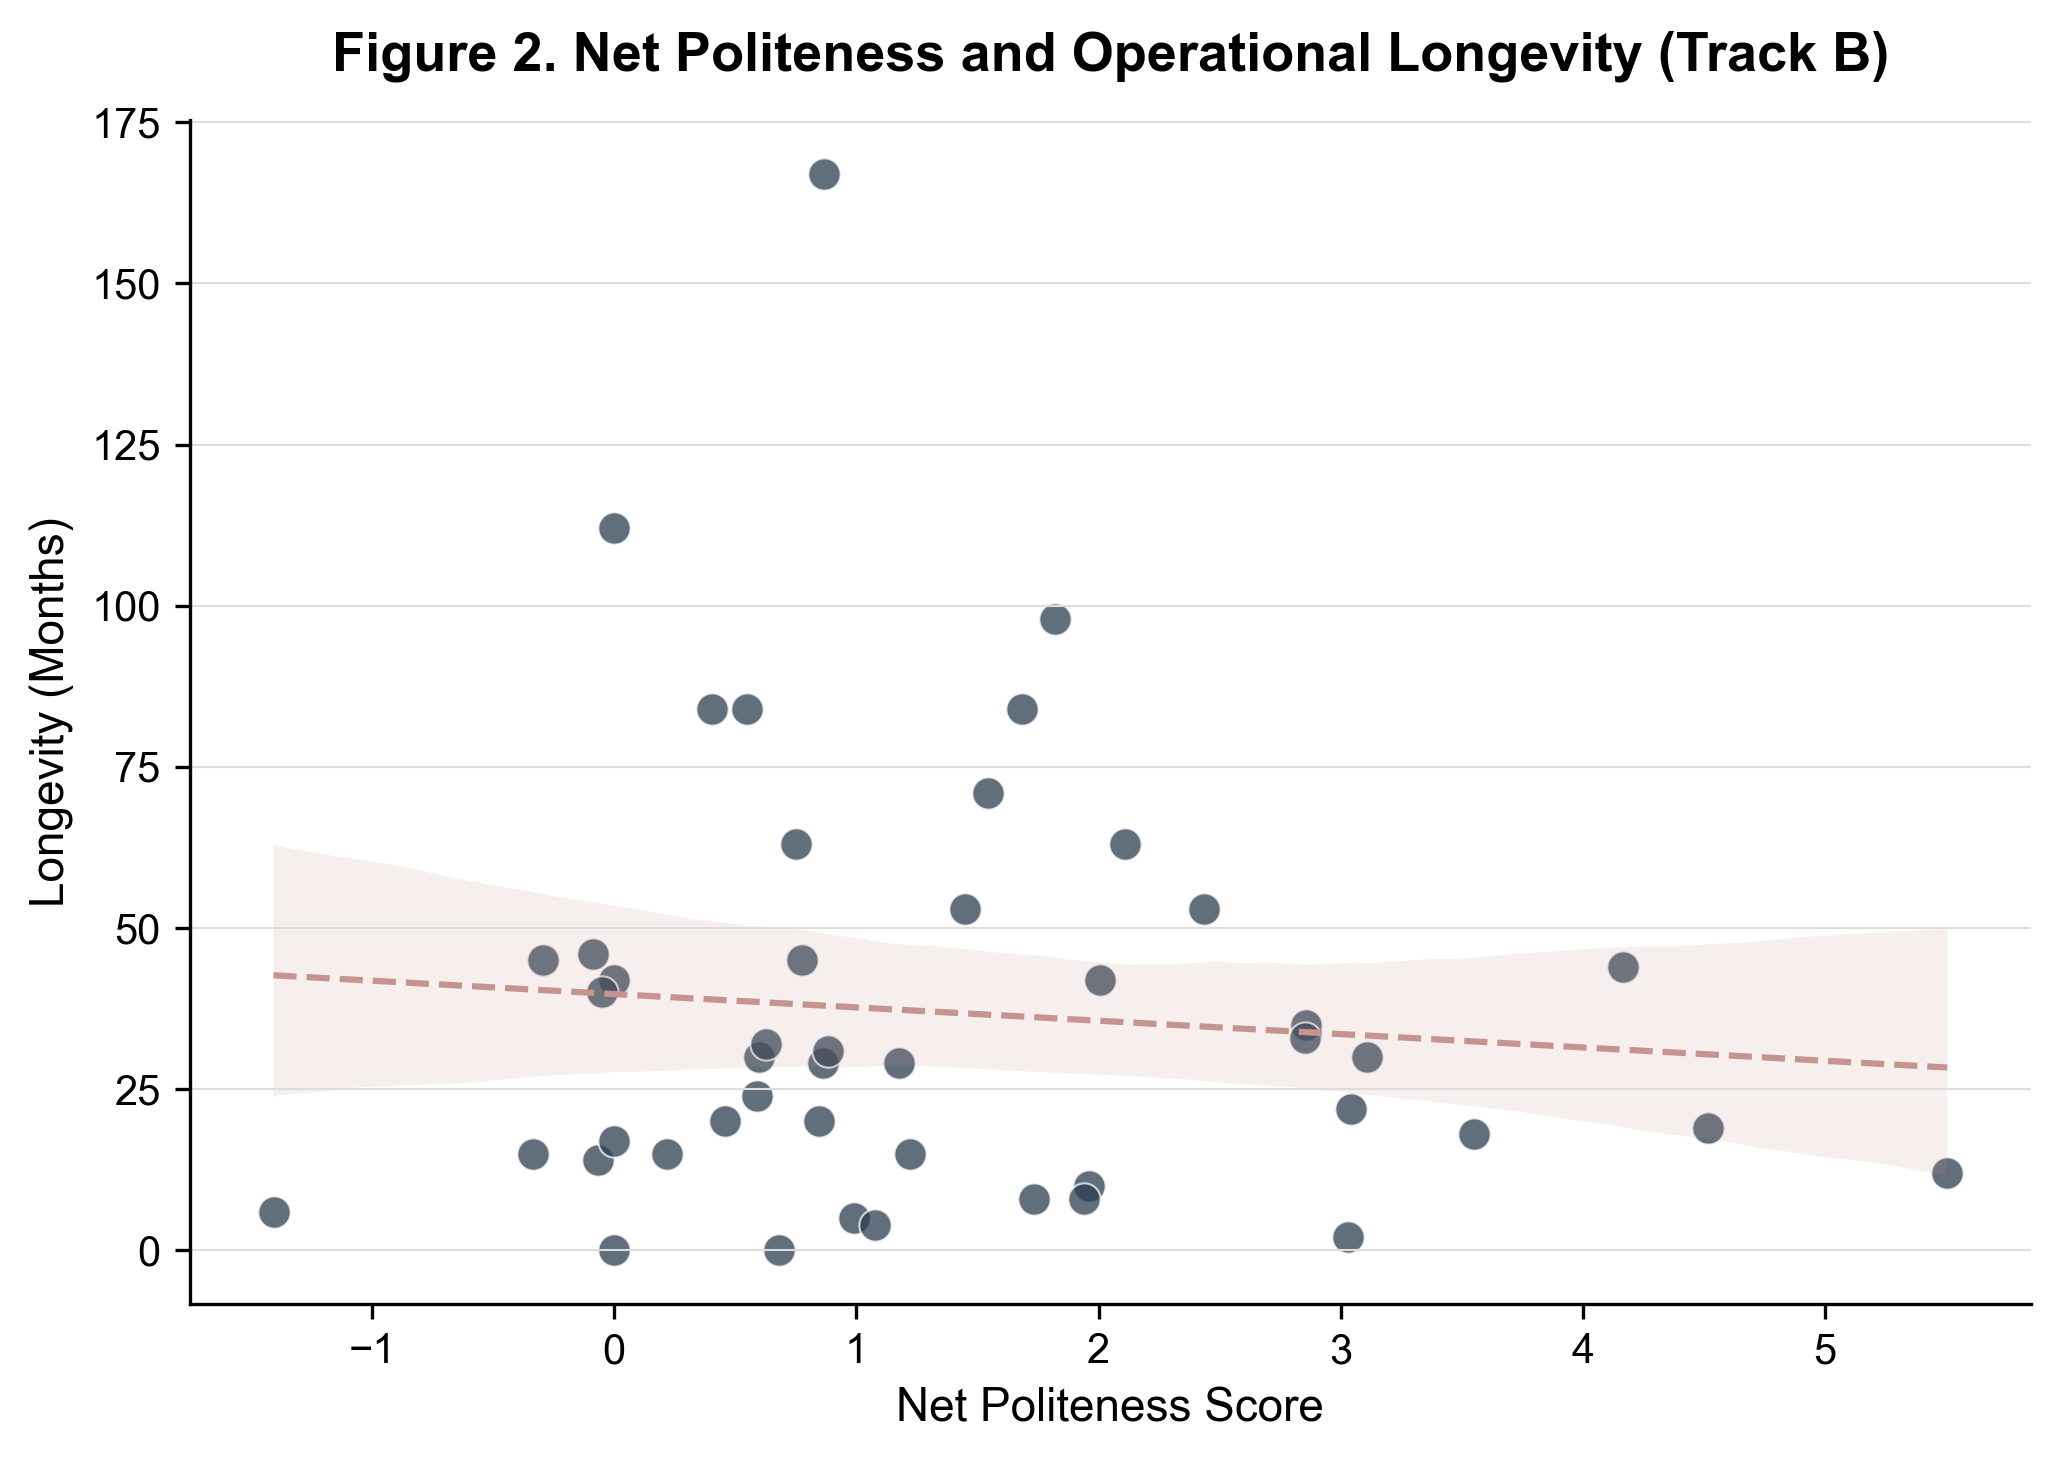

In [9]:
print("\n--- TRACK B: MID-MARKET ANALYSIS ---")

# --- PART 1: LONGEVITY (Survival) ---
corr_b_long = df_trackB['Net_Politeness'].corr(df_trackB['longevity_months'])
print(f"Correlation (Politeness vs Longevity): {corr_b_long:.3f}")

# Model: longevity_months = Intercept + Net_Politeness
model_b_long = smf.ols("longevity_months ~ Net_Politeness", data=df_trackB).fit()
print(model_b_long.summary())

# --- PART 2: VOLUME (Scale) ---
corr_b_vol = df_trackB['Net_Politeness'].corr(df_trackB['log_volume'])
print(f"Correlation (Politeness vs Volume): {corr_b_vol:.3f}")

# Model: log_volume = Intercept + Net_Politeness
model_b_vol = smf.ols("log_volume ~ Net_Politeness", data=df_trackB).fit()
print(model_b_vol.summary())

# --- Visualization (Focusing on Longevity) ---
fig, ax = plt.subplots(figsize=(7, 5))

sns.regplot(
    x='Net_Politeness', y='longevity_months',
    data=df_trackB,
    ax=ax,
    scatter_kws={
        's': 60,
        'color': '#2C3E50',
        'alpha': 0.75,
        'edgecolors': 'white',
        'linewidths': 0.5
    },
    line_kws={
        'color': "#C5948F",       # Grey line — signals non-significance visually
        'linewidth': 1.5,
        'linestyle': '--'
    },
    ci=95
)

ax.set_title('Figure 2. Net Politeness and Operational Longevity (Track B)',
             pad=12)
ax.set_xlabel('Net Politeness Score')
ax.set_ylabel('Longevity (Months)')
ax.yaxis.grid(True)
ax.xaxis.grid(False)

plt.tight_layout()
plt.savefig('TrackB_Longevity_Regression.png')
plt.show()


In [10]:
print("--- TRACK B: SPEARMAN VS PEARSON (LONGEVITY) ---")

# Calculate Pearson
pe_b, p_pe_b = pearsonr(df_trackB['Net_Politeness'], df_trackB['longevity_months'])

# Calculate Spearman
sp_b, p_sp_b = spearmanr(df_trackB['Net_Politeness'], df_trackB['longevity_months'])

print(f"Pearson:  r = {pe_b:.3f}, p = {p_pe_b:.3f}")
print(f"Spearman: r = {sp_b:.3f}, p = {p_sp_b:.3f}")

# If Spearman p-value is STILL > 0.05
# We can say that "even after correcting for severe data skew using non-parametric tests, politeness showed no relationship with survival."


--- TRACK B: SPEARMAN VS PEARSON (LONGEVITY) ---
Pearson:  r = -0.088, p = 0.558
Spearman: r = -0.018, p = 0.902


In [11]:
print("--- TRACK B: ROBUST STANDARD ERRORS (HC3) ---")

# Longevity Model
model_b_long_robust = smf.ols("longevity_months ~ Net_Politeness", data=df_trackB).fit(cov_type='HC3')
print("LONGEVITY ROBUST MODEL:")
print(model_b_long_robust.summary())


--- TRACK B: ROBUST STANDARD ERRORS (HC3) ---
LONGEVITY ROBUST MODEL:
                            OLS Regression Results                            
Dep. Variable:       longevity_months   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.014
Method:                 Least Squares   F-statistic:                    0.6054
Date:                Thu, 23 Apr 2026   Prob (F-statistic):              0.441
Time:                        20:14:54   Log-Likelihood:                -230.59
No. Observations:                  47   AIC:                             465.2
Df Residuals:                      45   BIC:                             468.9
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [12]:
print("--- TRACK B: CONTROLLING FOR START YEAR ---")

# We create a binary dummy: 1 if they started in 2021 or later, 0 if earlier
df_trackB['post_2021'] = (pd.to_datetime(df_trackB['first_seen']).dt.year >= 2021).astype(int)

# Run regression controlling for when they started
model_b_time = smf.ols("longevity_months ~ Net_Politeness + post_2021", data=df_trackB).fit(cov_type='HC3')
print(model_b_time.summary())

# Does Net_Politeness suddenly become significant once we account for the fact that newer groups haven't had time to live long?


--- TRACK B: CONTROLLING FOR START YEAR ---
                            OLS Regression Results                            
Dep. Variable:       longevity_months   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.260
Date:                Thu, 23 Apr 2026   Prob (F-statistic):              0.294
Time:                        20:14:54   Log-Likelihood:                -229.46
No. Observations:                  47   AIC:                             464.9
Df Residuals:                      44   BIC:                             470.5
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------


In [13]:
print("--- TRACK B: DECOMPOSING AGGRESSION VS. SERVICE ---")

model_b_decomp = smf.ols("longevity_months ~ Service_Score + Aggression_Score", data=df_trackB).fit(cov_type='HC3')
print(model_b_decomp.summary())

# Are either of these individual variables significant (p < 0.05) even though the combined Net_Politeness was not?


--- TRACK B: DECOMPOSING AGGRESSION VS. SERVICE ---
                            OLS Regression Results                            
Dep. Variable:       longevity_months   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.028
Method:                 Least Squares   F-statistic:                    0.3818
Date:                Thu, 23 Apr 2026   Prob (F-statistic):              0.685
Time:                        20:14:54   Log-Likelihood:                -230.37
No. Observations:                  47   AIC:                             466.7
Df Residuals:                      44   BIC:                             472.3
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

### TRACK B REGRESSION - VPC CONTROLLED MODEL
Expects VPC to be weak/non-significant — validating the structural difference between the two tracks.

In [14]:
print("--- TRACK B: VPC STANDALONE (expect weak — validates two-track design) ---")
df_trackB['post_2021'] = (pd.to_datetime(df_trackB['first_seen']).dt.year >= 2021).astype(int)

model_b_vpc_only = smf.ols("longevity_months ~ VPC_Index", data=df_trackB).fit(cov_type='HC3')
print(model_b_vpc_only.summary())
print("EXPECT: Weak/non-significant — mid-market groups operate outside the BGH premium structure.")

print("\n--- TRACK B: FULL MODEL — LONGEVITY (Net_Politeness + VPC + post_2021) ---")
model_b_full_vpc = smf.ols("longevity_months ~ Net_Politeness + VPC_Index + post_2021", data=df_trackB).fit(cov_type='HC3')
print(model_b_full_vpc.summary())
print("KEY: Net_Politeness non-significant → null holds even after controlling for victim type.")

print("\n--- TRACK B: FULL MODEL — VOLUME (log_volume + VPC + post_2021) ---")
model_b_vol_vpc = smf.ols("log_volume ~ Net_Politeness + VPC_Index + post_2021", data=df_trackB).fit(cov_type='HC3')
print(model_b_vol_vpc.summary())


--- TRACK B: VPC STANDALONE (expect weak — validates two-track design) ---
                            OLS Regression Results                            
Dep. Variable:       longevity_months   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     2.842
Date:                Thu, 23 Apr 2026   Prob (F-statistic):             0.0988
Time:                        20:14:54   Log-Likelihood:                -228.23
No. Observations:                  47   AIC:                             460.5
Df Residuals:                      45   BIC:                             464.2
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

**EXPORTING ROBUSTNESS CHECK TABLES:**

In [15]:
import pandas as pd
from stargazer.stargazer import Stargazer

# ===== TRACK A EXPORTS =====
# Baseline regression table (HTML for Word import)
stargazera = Stargazer([model_a])
stargazera.title("Table 1a: Track A Revenue Regression")
with open("Table1_TrackA_Baseline.html", "w", encoding="utf-8") as f:
    f.write(stargazera.render_html())
print("Track A Baseline Table saved → Table1_TrackA_Baseline.html")

# VPC regression table
stargazeravpc = Stargazer([model_a_vpc, model_a_full_vpc, model_a_interact])
stargazeravpc.title("Table 1b: Track A VPC Control Specifications")
stargazeravpc.custom_columns(["VPC Control", "Full Model", "Interaction"], [1, 1, 1])
with open("Table2_TrackA_VPC.html", "w", encoding="utf-8") as f:
    f.write(stargazeravpc.render_html())
print("Track A VPC Table saved → Table2_TrackA_VPC.html")

# ===== TRACK B EXPORTS =====
# Baseline regression table (HTML for Word import)
stargazerb = Stargazer([model_b_long])
stargazerb.title("Table 2a: Track B Longevity Regression")
with open("Table3_TrackB_Baseline.html", "w", encoding="utf-8") as f:
    f.write(stargazerb.render_html())
print("Track B Baseline Table saved → Table3_TrackB_Baseline.html")

# VPC regression table
stargazerbvpc = Stargazer([model_b_full_vpc, model_b_vol_vpc])
stargazerbvpc.title("Table 2b: Track B VPC Control Specifications")
stargazerbvpc.custom_columns(["Longevity + VPC", "Volume + VPC"], [1, 1])
with open("Table4_TrackB_VPC.html", "w", encoding="utf-8") as f:
    f.write(stargazerbvpc.render_html())
print("Track B VPC Table saved → Table4_TrackB_VPC.html")


Track A Baseline Table saved → Table1_TrackA_Baseline.html
Track A VPC Table saved → Table2_TrackA_VPC.html
Track B Baseline Table saved → Table3_TrackB_Baseline.html
Track B VPC Table saved → Table4_TrackB_VPC.html


## Final Results
Final results show a tier-dependent effect:
- Among elite groups, lower politeness and higher aggression are significantly associated with higher revenue, even after robustness checks including VPC control.
- Among mid-tier groups, linguistic tone has no measurable impact on survival.